# Propagation in shallow water (JAX)

This notebook demonstrates underwater acoustic propagation in shallow water using the JAX-based solver.
For the legacy NumPy/Cython version, see [uwa_shallow_water.ipynb](uwa_shallow_water.ipynb).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".." if "uwa" not in os.getcwd() else "../..", "..", "..", "..")))
# Handle running from docs/source/notebooks or project root
for p in [".", "..", "../..", "../../..", "../../../.."]:
    full = os.path.abspath(p)
    if os.path.exists(os.path.join(full, "pywaveprop")):
        sys.path.insert(0, full)
        break


In [2]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from pywaveprop.experimental.uwa_jax import (
    UWAGaussSourceModel,
    UnderwaterLayerModel,
    UnderwaterEnvironmentModel,
    uwa_forward_task,
)
from pywaveprop.experimental.uwa_utils import UWAComputationalParams
from pywaveprop.experimental.helmholtz_jax import ConstWaveSpeedModel

## Preparing environment

Constant sound speed, flat bottom at 300 m.

In [3]:
max_range_m = 3000

env = UnderwaterEnvironmentModel(layers=[
    UnderwaterLayerModel(
        height_m=300,
        sound_speed_profile_m_s=ConstWaveSpeedModel(c0=1500),
        density=1.0,
    ),
    UnderwaterLayerModel(
        height_m=200,
        sound_speed_profile_m_s=ConstWaveSpeedModel(c0=1700),
        density=1.5,
        attenuation_dm_lambda=0.01,
    ),
])

## Source: 1 kHz, 100 m depth, downward beam

In [4]:
src = UWAGaussSourceModel(
    freq_hz=1000,
    depth_m=100,
    beam_width_deg=1,
    elevation_angle_deg=-30,
    multiplier=5,
)

In [5]:
params = UWAComputationalParams(
    max_range_m=max_range_m,
    max_depth_m=500,
    dx_m=1,
    dz_m=1,
)

field = uwa_forward_task(src, env, params)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


k_min: 3.6959913571644623, k_max: 4.1887902047863905
rational_approx_order: (3, 4), beta: 3.434628149388195, dx: 0.5, dz: 0.045454545454545456


### 2D field distribution

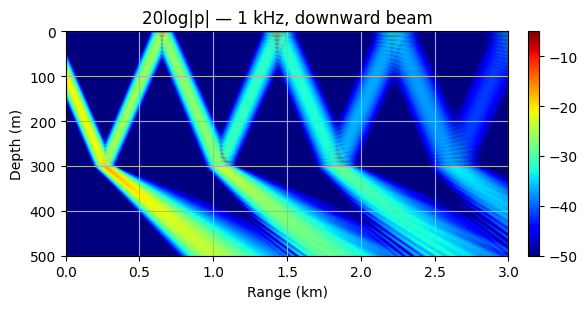

In [6]:
def plot_uwa_2d(field, title='', vmin=-50, vmax=-5):
    data = 20 * np.log10(np.abs(np.asarray(field.field)) + 1e-16).real
    extent = [field.x_grid[0]*1e-3, field.x_grid[-1]*1e-3,
              field.z_grid[-1], field.z_grid[0]]
    plt.figure(figsize=(6, 3.2))
    plt.imshow(data.T, extent=extent, norm=Normalize(vmin, vmax),
               aspect='auto', cmap='jet')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xlabel('Range (km)')
    plt.ylabel('Depth (m)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_uwa_2d(field, '20log|p| — 1 kHz, downward beam')

## Source: 200 Hz, 150 m depth, upward beam

k_min: 0.7391982714328925, k_max: 0.8377580409572782
rational_approx_order: (2, 3), beta: 0.7064366144028968, dx: 0.5, dz: 0.5


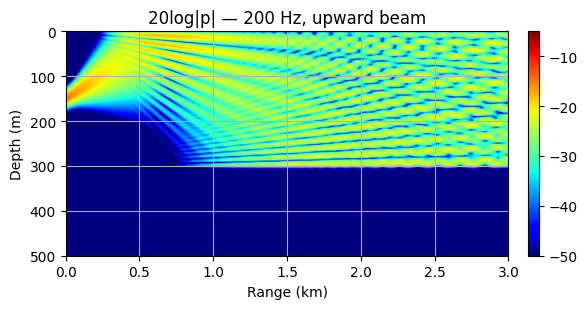

In [7]:
src2 = UWAGaussSourceModel(
    freq_hz=200,
    depth_m=150,
    beam_width_deg=10,
    elevation_angle_deg=10,
    multiplier=5,
)

field2 = uwa_forward_task(src2, env, params)
plot_uwa_2d(field2, '20log|p| — 200 Hz, upward beam')